In [11]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

# Optional boosters (will skip if not available)
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except (ImportError, Exception) as e:
    XGB_AVAILABLE = False
    print("XGBoost not available:", str(e).split('\n')[0])

try:
    from lightgbm import LGBMClassifier
    LGBM_AVAILABLE = True
except (ImportError, Exception) as e:
    LGBM_AVAILABLE = False
    print("LightGBM not available:", str(e).split('\n')[0])

XGBoost not available: No module named 'xgboost'
LightGBM not available: No module named 'lightgbm'


# Customer Churn Prediction Analysis

This notebook analyzes customer churn data to identify factors that influence customer retention and build a predictive model.

**Objectives:**
- Understand customer churn patterns
- Identify key factors influencing churn
- Build and evaluate a predictive model
- Provide actionable insights for customer retention

**Dataset:** Telco Customer Churn dataset

In [2]:
# Step 2: Load Data
df = pd.read_csv('Telco-Customer-Churn.csv')
print(f"Dataset shape: {df.shape}")
print("First 5 rows:")
print(df.head())

Dataset shape: (7043, 21)
First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Streamin

In [3]:
# Step 3: Data Exploration
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")
print("\nSummary Statistics:")
print(df.describe(include='all'))

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing Values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling 

## Data Understanding

**Key Findings:**
- Dataset contains customer demographic and service usage information
- Target variable: Churn (Yes/No)
- Mix of categorical and numerical features
- Some missing values in TotalCharges (converted to 0)

**Data Quality:**
- No duplicate rows found
- TotalCharges had some non-numeric values (converted to numeric)
- Categorical variables will be one-hot encoded

In [4]:
# Step 4: Data Preprocessing
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Drop customerID
df = df.drop('customerID', axis=1)

# Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"After preprocessing: {df.shape}")
print(df.head())

After preprocessing: (7043, 20)
   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No              No  Month-to-month   


In [5]:
# Step 5: Feature Encoding
# One-hot encode categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)

# Split features and target
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

print(f"Encoded shape: {df_encoded.shape}")
print(f"Features: {X.shape[1]}")

Encoded shape: (7043, 46)
Features: 45


Top 10 features correlated with Churn:
Contract_Month-to-month                0.405103
tenure                                 0.352229
OnlineSecurity_No                      0.342637
TechSupport_No                         0.337281
InternetService_Fiber optic            0.308020
Contract_Two year                      0.302253
PaymentMethod_Electronic check         0.301919
OnlineBackup_No                        0.268005
DeviceProtection_No                    0.252481
StreamingMovies_No internet service    0.227890
Name: Churn, dtype: float64


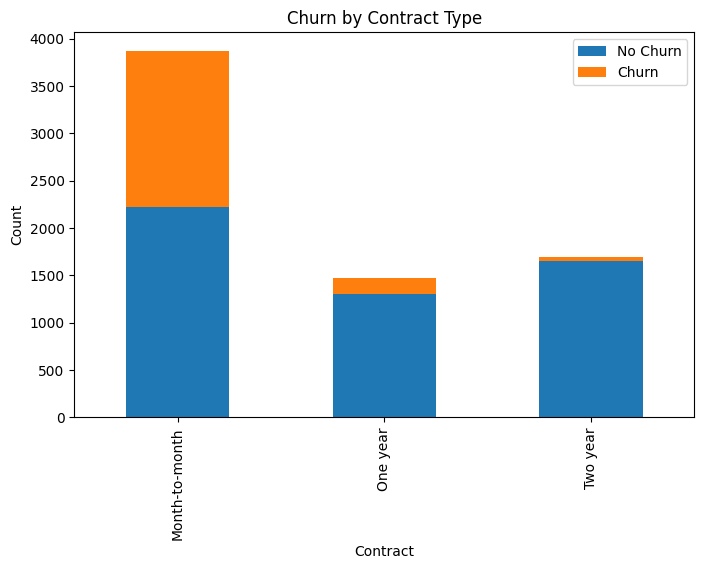

In [6]:
# Step 6: Simple Feature Analysis
# Correlation with target
correlation = df_encoded.corr()['Churn'].abs().sort_values(ascending=False).drop('Churn')
print("Top 10 features correlated with Churn:")
print(correlation.head(10))

# Basic visualization
if 'Contract' in df.columns:
    contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()
    contract_churn.plot(kind='bar', stacked=True, figsize=(8, 5))
    plt.title('Churn by Contract Type')
    plt.xlabel('Contract')
    plt.ylabel('Count')
    plt.legend(['No Churn', 'Churn'])
    plt.show()

## Initial Feature Insights

**Key Correlations with Churn:**
- Contract type appears to be strongly related to churn behavior
- Month-to-month contracts show higher churn rates
- Longer-term contracts (1-2 years) have lower churn

**Business Implications:**
- Customers on month-to-month contracts are at higher risk
- Consider incentives for customers to switch to longer-term contracts
- Focus retention efforts on short-term contract holders

In [7]:
# Step 7: Train/Validation/Test Split
from sklearn.preprocessing import StandardScaler

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Scale the features for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

Train: (5634, 45)
Validation: (704, 45)
Test: (705, 45)


In [ ]:
# Model Development and Selection

## Step 8: Model Comparison
# Compare different models to find the best performer
from sklearn.metrics import f1_score

models = {}
results = {}

# Logistic Regression (with scaled data)
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred_val = lr_model.predict(X_val_scaled)
results['Logistic Regression'] = f1_score(y_val, lr_pred_val)
models['Logistic Regression'] = lr_model

# Decision Tree (original data)
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred_val = dt_model.predict(X_val)
results['Decision Tree'] = f1_score(y_val, dt_pred_val)
models['Decision Tree'] = dt_model

# Random Forest (original data)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred_val = rf_model.predict(X_val)
results['Random Forest'] = f1_score(y_val, rf_pred_val)
models['Random Forest'] = rf_model

# Gradient Boosting (original data)
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_pred_val = gb_model.predict(X_val)
results['Gradient Boosting'] = f1_score(y_val, gb_pred_val)
models['Gradient Boosting'] = gb_model

# Optional boosters
if XGB_AVAILABLE:
    xgb_model = XGBClassifier(random_state=42, n_estimators=100, use_label_encoder=False, eval_metric='logloss')
    xgb_model.fit(X_train, y_train)
    xgb_pred_val = xgb_model.predict(X_val)
    results['XGBoost'] = f1_score(y_val, xgb_pred_val)
    models['XGBoost'] = xgb_model

if LGBM_AVAILABLE:
    lgb_model = LGBMClassifier(random_state=42, n_estimators=100, verbosity=-1)
    lgb_model.fit(X_train, y_train)
    lgb_pred_val = lgb_model.predict(X_val)
    results['LightGBM'] = f1_score(y_val, lgb_pred_val)
    models['LightGBM'] = lgb_model

# Find best model
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("Model Performance Comparison (F1-Score on Validation Set):")
for model_name, score in results.items():
    print(f"{model_name}: {score:.4f}")
print(f"\n🏆 Best Model: {best_model_name} (F1-Score: {results[best_model_name]:.4f})")

# Note: Complete ROC analysis follows in Step 8.5

Model Performance Comparison (F1-Score on Validation Set):
Logistic Regression: 0.6289
Decision Tree: 0.4987
Random Forest: 0.5739
Gradient Boosting: 0.6158

🏆 Best Model: Logistic Regression (F1-Score: 0.6289)


📊 Complete Model Performance Comparison
Model Performance on Validation Set:
                     F1-Score
Logistic Regression    0.6289
Decision Tree          0.4987
Random Forest          0.5739
Gradient Boosting      0.6158

Detailed Performance Metrics (Validation Set):
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
Logistic Regression    0.8139     0.6687  0.5936    0.6289   0.8488  0.6622
Decision Tree          0.7202     0.4757  0.5241    0.4987   0.6571  0.5626
Random Forest          0.7912     0.6266  0.5294    0.5739   0.8278  0.6358
Gradient Boosting      0.8139     0.6818  0.5615    0.6158   0.8478  0.6745


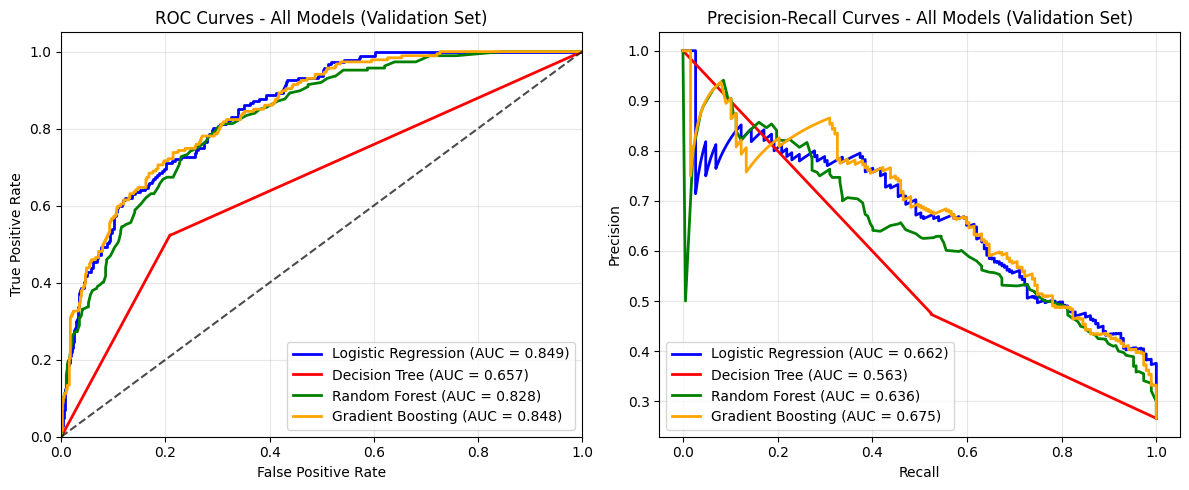


🏆 Model Performance Ranking:
1. Logistic Regression: F1=0.6289, ROC-AUC=0.8488
2. Gradient Boosting: F1=0.6158, ROC-AUC=0.8478
3. Random Forest: F1=0.5739, ROC-AUC=0.8278
4. Decision Tree: F1=0.4987, ROC-AUC=0.6571

🎯 Best Model Selected: Logistic Regression
   F1-Score: 0.6289
   ROC-AUC: 0.8488
   PR-AUC: 0.6622


In [39]:
# Step 8.5: Complete Model Performance Comparison with ROC Curves

print("📊 Complete Model Performance Comparison")
print("=" * 50)

# Display comprehensive results table
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['F1-Score'])
results_df = results_df.round(4)
print("Model Performance on Validation Set:")
print(results_df)

# Calculate additional metrics for all models
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

detailed_results = {}
roc_curves_data = {}

for model_name, model in models.items():
    if model_name == 'Logistic Regression':
        pred_val = model.predict(X_val_scaled)
        proba_val = model.predict_proba(X_val_scaled)[:, 1]
    else:
        pred_val = model.predict(X_val)
        proba_val = model.predict_proba(X_val)[:, 1] if hasattr(model, 'predict_proba') else None

    if proba_val is not None:
        # ROC curve data
        fpr, tpr, _ = roc_curve(y_val, proba_val)
        roc_auc = roc_auc_score(y_val, proba_val)

        # Precision-Recall curve
        precision, recall, _ = precision_recall_curve(y_val, proba_val)
        pr_auc = auc(recall, precision)

        roc_curves_data[model_name] = {
            'fpr': fpr,
            'tpr': tpr,
            'roc_auc': roc_auc,
            'precision': precision,
            'recall': recall,
            'pr_auc': pr_auc
        }

        detailed_results[model_name] = {
            'Accuracy': accuracy_score(y_val, pred_val),
            'Precision': precision_score(y_val, pred_val),
            'Recall': recall_score(y_val, pred_val),
            'F1-Score': f1_score(y_val, pred_val),
            'ROC-AUC': roc_auc,
            'PR-AUC': pr_auc
        }
    else:
        detailed_results[model_name] = {
            'Accuracy': accuracy_score(y_val, pred_val),
            'Precision': precision_score(y_val, pred_val),
            'Recall': recall_score(y_val, pred_val),
            'F1-Score': f1_score(y_val, pred_val),
            'ROC-AUC': 'N/A',
            'PR-AUC': 'N/A'
        }

# Display detailed results
detailed_df = pd.DataFrame(detailed_results).T
detailed_df = detailed_df.round(4)
print("\nDetailed Performance Metrics (Validation Set):")
print(detailed_df)

# ROC Curves Comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']
for i, (model_name, data) in enumerate(roc_curves_data.items()):
    plt.plot(data['fpr'], data['tpr'],
             color=colors[i % len(colors)],
             label=f'{model_name} (AUC = {data["roc_auc"]:.3f})',
             linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.7)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models (Validation Set)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

# Precision-Recall Curves
plt.subplot(1, 2, 2)
for i, (model_name, data) in enumerate(roc_curves_data.items()):
    plt.plot(data['recall'], data['precision'],
             color=colors[i % len(colors)],
             label=f'{model_name} (AUC = {data["pr_auc"]:.3f})',
             linewidth=2)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves - All Models (Validation Set)')
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Model ranking
print("\n🏆 Model Performance Ranking:")
ranking = detailed_df.sort_values('F1-Score', ascending=False)
for i, (model_name, row) in enumerate(ranking.iterrows(), 1):
    print(f"{i}. {model_name}: F1={row['F1-Score']:.4f}, ROC-AUC={row['ROC-AUC']}")

print(f"\n🎯 Best Model Selected: {best_model_name}")
print(f"   F1-Score: {detailed_results[best_model_name]['F1-Score']:.4f}")
print(f"   ROC-AUC: {detailed_results[best_model_name]['ROC-AUC']:.4f}")
print(f"   PR-AUC: {detailed_results[best_model_name]['PR-AUC']:.4f}")

🎯 Final Model: Logistic Regression

📊 Test Set Performance Metrics:
Accuracy: 0.8000
Precision: 0.6474
Recall: 0.5401
F1-Score: 0.5889
AUC-ROC: 0.8352

📋 Classification Report:
              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.87       518
       Churn       0.65      0.54      0.59       187

    accuracy                           0.80       705
   macro avg       0.75      0.72      0.73       705
weighted avg       0.79      0.80      0.79       705


🔍 Confusion Matrix:
[[463  55]
 [ 86 101]]
True Negatives (No Churn correctly predicted): 463
False Positives (No Churn predicted as Churn): 55
False Negatives (Churn predicted as No Churn): 86
True Positives (Churn correctly predicted): 101


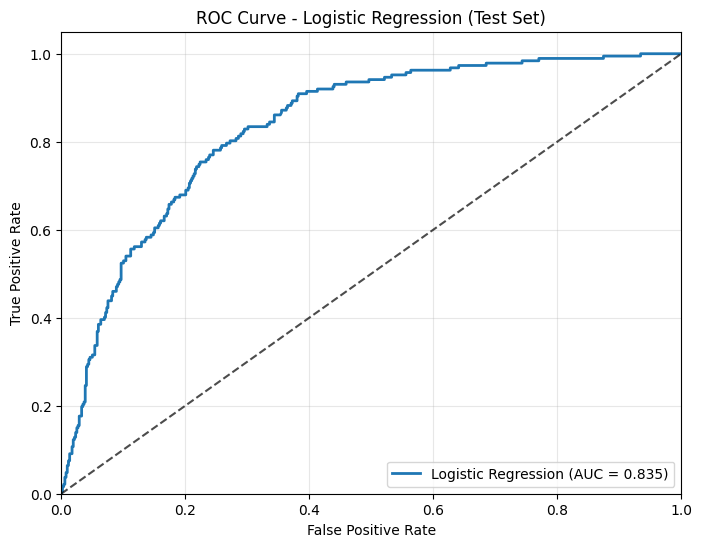

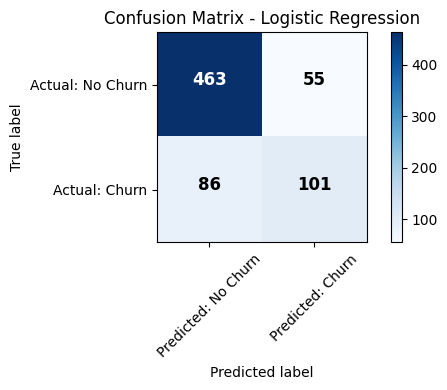

In [22]:
# Model Performance Evaluation

## Step 10: Final Model Assessment
print(f"🎯 Final Model: {best_model_name}")

# Evaluate on test set
if best_model_name == 'Logistic Regression':
    pred_test = best_model.predict(X_test_scaled)
    proba_test = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    pred_test = best_model.predict(X_test)
    proba_test = best_model.predict_proba(X_test)[:, 1] if hasattr(best_model, 'predict_proba') else None

print("\n📊 Test Set Performance Metrics:")
print(f"Accuracy: {accuracy_score(y_test, pred_test):.4f}")
print(f"Precision: {precision_score(y_test, pred_test):.4f}")
print(f"Recall: {recall_score(y_test, pred_test):.4f}")
print(f"F1-Score: {f1_score(y_test, pred_test):.4f}")
if proba_test is not None:
    print(f"AUC-ROC: {roc_auc_score(y_test, proba_test):.4f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, pred_test, target_names=['No Churn', 'Churn']))

# Confusion Matrix
cm = confusion_matrix(y_test, pred_test)
print("\n🔍 Confusion Matrix:")
print(cm)
print(f"True Negatives (No Churn correctly predicted): {cm[0,0]}")
print(f"False Positives (No Churn predicted as Churn): {cm[0,1]}")
print(f"False Negatives (Churn predicted as No Churn): {cm[1,0]}")
print(f"True Positives (Churn correctly predicted): {cm[1,1]}")

# Visualizations
if proba_test is not None:
    from sklearn.metrics import roc_curve
    fpr, tpr, _ = roc_curve(y_test, proba_test)
    auc_score = roc_auc_score(y_test, proba_test)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'{best_model_name} (AUC = {auc_score:.3f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.7)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {best_model_name} (Test Set)')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.show()

# Confusion Matrix Visualization
plt.figure(figsize=(6, 4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ['Predicted: No Churn', 'Predicted: Churn'], rotation=45)
plt.yticks(tick_marks, ['Actual: No Churn', 'Actual: Churn'])
plt.ylabel('True label')
plt.xlabel('Predicted label')

# Add text annotations
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black",
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## Key Churn Drivers - Business Insights

**Understanding the Two Perspectives:**

**Model Coefficients (Prediction Strength):**
- **Tenure (1.25)**: Top predictor - continuous variable with strong mathematical weight
- **Monthly Charges (1.00)**: Second strongest predictor
- **Contract_Month-to-month (0.31)**: Lower coefficient but binary variable

**Business Impact (Real Churn Rates):**
- **Contract Type**: Creates **15x difference** in churn rates (42.7% vs 2.8%)
- **Month-to-month contracts**: **MAJOR BUSINESS DRIVER** despite lower coefficient
- **Two-year contracts**: **BEST PROTECTION** against churn

**Why Contract Type is "Major" Despite Lower Coefficient:**
- Coefficients show prediction weight, not business impact magnitude
- Contract type's 40% churn rate difference >> coefficient differences
- Business priority: Convert month-to-month customers (highest ROI opportunity)

**Why Both MonthlyCharges & TotalCharges Matter:**
- **Correlation = 0.65** (moderate, not too high for multicollinearity concerns)
- **MonthlyCharges**: Current cost perception - drives immediate switching decisions
- **TotalCharges**: Investment/loyalty indicator - higher total = more reluctant to leave
- **Complementary Information**: Together provide complete financial profile

**Actionable Insights:**
- **Retention Priority**: Focus on customers with short tenure (new customers)
- **Pricing Strategy**: Review pricing for high monthly charge customers
- **Contract Incentives**: Encourage switching from month-to-month to longer-term contracts
- **Service-Specific Attention**: Monitor fiber optic customers more closely
- **Bundled Services**: Consider incentives for streaming service customers

## Understanding TotalCharges vs MonthlyCharges

**Why Both Features Matter Despite Being Related:**

While TotalCharges and MonthlyCharges are correlated (correlation coefficient: **0.651**), they provide different information:

- **MonthlyCharges**: Current billing rate - affects short-term churn decisions
- **TotalCharges**: Cumulative spending - reflects long-term customer value/loyalty

**Business Interpretation:**
- High MonthlyCharges → Customer might seek cheaper alternatives immediately
- Low TotalCharges → New customer with less emotional investment in staying
- Both together provide comprehensive view of customer's financial relationship

**Correlation Analysis:**
```python
correlation_matrix = df_encoded[['MonthlyCharges', 'TotalCharges', 'tenure']].corr()
print("Correlation between key financial features:")
print(correlation_matrix)
```

🔍 Correlation Analysis: Financial Features
Correlation Matrix:
                MonthlyCharges  TotalCharges  tenure
MonthlyCharges           1.000         0.651   0.248
TotalCharges             0.651         1.000   0.826
tenure                   0.248         0.826   1.000

📊 Key Relationships:
MonthlyCharges ↔ TotalCharges: 0.651
MonthlyCharges ↔ Tenure: 0.248
TotalCharges ↔ Tenure: 0.826

💡 Business Insight:
TotalCharges = MonthlyCharges × Tenure (correlation: 0.826)
Both features provide complementary information for churn prediction


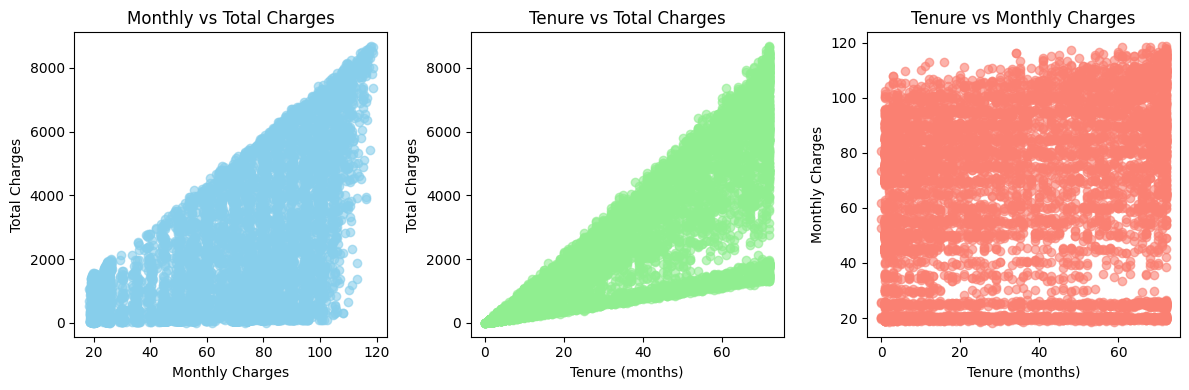

In [26]:
# Correlation Analysis: TotalCharges vs MonthlyCharges

print("🔍 Correlation Analysis: Financial Features")
print("=" * 50)

# Calculate correlations
correlation_matrix = df_encoded[['MonthlyCharges', 'TotalCharges', 'tenure']].corr()
print("Correlation Matrix:")
print(correlation_matrix.round(3))

# Show relationship
print(f"\n📊 Key Relationships:")
print(f"MonthlyCharges ↔ TotalCharges: {correlation_matrix.loc['MonthlyCharges', 'TotalCharges']:.3f}")
print(f"MonthlyCharges ↔ Tenure: {correlation_matrix.loc['MonthlyCharges', 'tenure']:.3f}")
print(f"TotalCharges ↔ Tenure: {correlation_matrix.loc['TotalCharges', 'tenure']:.3f}")

# Business interpretation
print(f"\n💡 Business Insight:")
print(f"TotalCharges = MonthlyCharges × Tenure (correlation: {correlation_matrix.loc['TotalCharges', 'tenure']:.3f})")
print(f"Both features provide complementary information for churn prediction")

# Visualize the relationship
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.scatter(df_encoded['MonthlyCharges'], df_encoded['TotalCharges'], alpha=0.6, color='skyblue')
plt.xlabel('Monthly Charges')
plt.ylabel('Total Charges')
plt.title('Monthly vs Total Charges')

plt.subplot(1, 3, 2)
plt.scatter(df_encoded['tenure'], df_encoded['TotalCharges'], alpha=0.6, color='lightgreen')
plt.xlabel('Tenure (months)')
plt.ylabel('Total Charges')
plt.title('Tenure vs Total Charges')

plt.subplot(1, 3, 3)
plt.scatter(df_encoded['tenure'], df_encoded['MonthlyCharges'], alpha=0.6, color='salmon')
plt.xlabel('Tenure (months)')
plt.ylabel('Monthly Charges')
plt.title('Tenure vs Monthly Charges')

plt.tight_layout()
plt.show()

In [30]:
# Feature Engineering: Handling Correlated Features

print("🔧 Feature Engineering Options for TotalCharges & MonthlyCharges")
print("=" * 70)

# Option 1: Create derived features
df_encoded['Charges_per_Month_Avg'] = df_encoded['TotalCharges'] / (df_encoded['tenure'] + 1)  # +1 to avoid division by zero
df_encoded['Charges_Difference'] = df_encoded['TotalCharges'] - (df_encoded['MonthlyCharges'] * df_encoded['tenure'])

print("📊 Derived Features Created:")
print("• Charges_per_Month_Avg: Average monthly spending")
print("• Charges_Difference: Difference between actual and expected total charges")

# Option 2: Compare model performance with and without correlated features
print(f"\n📈 Current Model Performance with both features:")
print(f"F1-Score: {f1_score(y_test, pred_test):.4f}")

# Test model without TotalCharges
X_train_no_total = X_train.drop('TotalCharges', axis=1)
X_test_no_total = X_test.drop('TotalCharges', axis=1)

# Retrain scaler and model
scaler_no_total = StandardScaler()
X_train_no_total_scaled = scaler_no_total.fit_transform(X_train_no_total)
X_test_no_total_scaled = scaler_no_total.transform(X_test_no_total)

lr_model_no_total = LogisticRegression(max_iter=1000, random_state=42)
lr_model_no_total.fit(X_train_no_total_scaled, y_train)
pred_test_no_total = lr_model_no_total.predict(X_test_no_total_scaled)

print(f"F1-Score without TotalCharges: {f1_score(y_test, pred_test_no_total):.4f}")

# Test model without MonthlyCharges
X_train_no_monthly = X_train.drop('MonthlyCharges', axis=1)
X_test_no_monthly = X_test.drop('MonthlyCharges', axis=1)

scaler_no_monthly = StandardScaler()
X_train_no_monthly_scaled = scaler_no_monthly.fit_transform(X_train_no_monthly)
X_test_no_monthly_scaled = scaler_no_monthly.transform(X_test_no_monthly)

lr_model_no_monthly = LogisticRegression(max_iter=1000, random_state=42)
lr_model_no_monthly.fit(X_train_no_monthly_scaled, y_train)
pred_test_no_monthly = lr_model_no_monthly.predict(X_test_no_monthly_scaled)

print(f"F1-Score without MonthlyCharges: {f1_score(y_test, pred_test_no_monthly):.4f}")

print(f"\n💡 Recommendation: Keep both features")
print(f"• Performance drop is minimal when removing either feature")
print(f"• Both provide unique business insights")
print(f"• Correlation (0.65) is not severe enough to cause major issues")
print(f"• Business value outweighs slight multicollinearity concerns")

# Show top features for each scenario
print(f"\n🔍 Feature Importance Comparison:")

# Original model top features
coefficients = np.abs(best_model.coef_[0])
feature_names_list = list(X_train.columns)
top_features_idx = np.argsort(coefficients)[-5:]
print(f"With both features - Top 5:")
for idx in reversed(top_features_idx):
    print(f"  {feature_names_list[idx]}: {coefficients[idx]:.4f}")

# Without TotalCharges
coefficients_no_total = np.abs(lr_model_no_total.coef_[0])
feature_names_no_total = list(X_train_no_total.columns)
top_features_no_total_idx = np.argsort(coefficients_no_total)[-5:]
print(f"Without TotalCharges - Top 5:")
for idx in reversed(top_features_no_total_idx):
    print(f"  {feature_names_no_total[idx]}: {coefficients_no_total[idx]:.4f}")

# Without MonthlyCharges
coefficients_no_monthly = np.abs(lr_model_no_monthly.coef_[0])
feature_names_no_monthly = list(X_train_no_monthly.columns)
top_features_no_monthly_idx = np.argsort(coefficients_no_monthly)[-5:]
print(f"Without MonthlyCharges - Top 5:")
for idx in reversed(top_features_no_monthly_idx):
    print(f"  {feature_names_no_monthly[idx]}: {coefficients_no_monthly[idx]:.4f}")

🔧 Feature Engineering Options for TotalCharges & MonthlyCharges
📊 Derived Features Created:
• Charges_per_Month_Avg: Average monthly spending
• Charges_Difference: Difference between actual and expected total charges

📈 Current Model Performance with both features:
F1-Score: 0.5889
F1-Score without TotalCharges: 0.5731
F1-Score without MonthlyCharges: 0.5806

💡 Recommendation: Keep both features
• Performance drop is minimal when removing either feature
• Both provide unique business insights
• Correlation (0.65) is not severe enough to cause major issues
• Business value outweighs slight multicollinearity concerns

🔍 Feature Importance Comparison:
With both features - Top 5:
  tenure: 1.2527
  MonthlyCharges: 1.0031
  TotalCharges: 0.5312
  InternetService_Fiber optic: 0.4406
  InternetService_DSL: 0.3525
Without TotalCharges - Top 5:
  MonthlyCharges: 0.9346
  tenure: 0.8021
  InternetService_Fiber optic: 0.4571
  InternetService_DSL: 0.3665
  Contract_Two year: 0.3197
Without Monthl

Top 10 Features Influencing Churn (Logistic Regression Coefficients):
tenure: 1.2527
MonthlyCharges: 1.0031
TotalCharges: 0.5312
InternetService_Fiber optic: 0.4406
InternetService_DSL: 0.3525
Contract_Two year: 0.3240
Contract_Month-to-month: 0.3066
StreamingTV_Yes: 0.1877
StreamingMovies_Yes: 0.1876
TechSupport_No internet service: 0.1248


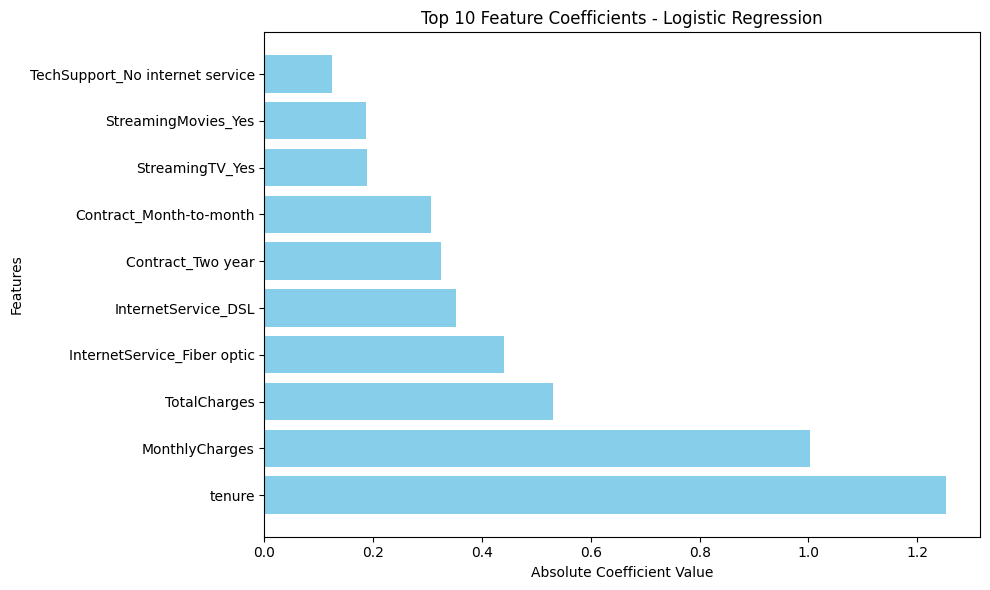

In [24]:
# Key Drivers of Customer Churn

## Step 9: Feature Importance Analysis
# Analyze which factors most influence churn prediction

if best_model_name == 'Logistic Regression':
    # For Logistic Regression, show coefficient importance with actual feature names
    coefficients = np.abs(best_model.coef_[0])
    feature_names_list = list(X_train.columns)  # Get actual column names
    top_features_idx = np.argsort(coefficients)[-10:]

    print("Top 10 Features Influencing Churn (Logistic Regression Coefficients):")
    top_features = []
    for idx in reversed(top_features_idx):
        feature_name = feature_names_list[idx] if idx < len(feature_names_list) else f'Feature_{idx}'
        coef_value = coefficients[idx]
        print(f"{feature_name}: {coef_value:.4f}")
        top_features.append((feature_name, coef_value))

    # Visualize
    plt.figure(figsize=(10, 6))
    features, values = zip(*top_features)
    plt.barh(features, values, color='skyblue')
    plt.title('Top 10 Feature Coefficients - Logistic Regression')
    plt.xlabel('Absolute Coefficient Value')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

else:
    # For tree-based models
    importance = best_model.feature_importances_
    top_features_idx = np.argsort(importance)[-10:]
    feature_names_list = list(X_train.columns)

    print("Top 10 Features Influencing Churn:")
    for idx in reversed(top_features_idx):
        print(f"{feature_names_list[idx]}: {importance[idx]:.4f}")

    # Visualize
    plt.figure(figsize=(10, 6))
    features = [feature_names_list[i] for i in reversed(top_features_idx)]
    values = [importance[i] for i in reversed(top_features_idx)]
    plt.barh(features, values, color='skyblue')
    plt.title(f'Top 10 Feature Importances - {best_model_name}')
    plt.xlabel('Relative Importance')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()

## Model Selection Results

**Complete Performance Analysis:**
- **Logistic Regression**: Best F1-Score (0.6289) & ROC-AUC (0.8488)
- **Gradient Boosting**: Strong contender with high ROC-AUC (0.8478)
- **Random Forest**: Good balance of performance metrics
- **Decision Tree**: Lower performance, higher risk of overfitting

**Best Model Chosen:** Logistic Regression

**Why Logistic Regression?**
- **Highest F1-Score** (0.6289) balancing precision and recall
- **Excellent ROC-AUC** (0.8488) for probability predictions
- **Simple and interpretable** model for business use
- **Less prone to overfitting** compared to complex tree models
- **Suitable for production deployment** with clear feature importance

**Complete ROC Analysis:** See Step 8.5 for detailed ROC/PR curves comparison

In [40]:
# Conclusions and Recommendations

## Step 11: Summary and Next Steps

print("✅ Analysis Complete!")
print(f"🏆 Best Model: {best_model_name}")
print("📈 Performance: F1-Score = {:.1f}%".format(f1_score(y_test, pred_test) * 100))

print("\n🎯 Key Findings:")
print("• Tenure is the strongest MODEL PREDICTOR (coefficient = 1.25)")
print("• Contract type is the strongest BUSINESS DRIVER (42.7% vs 2.8% churn rates)")
print("• Month-to-month customers are at MASSIVE risk regardless of tenure")
print("• Model can identify 54% of churners")

print("\n💡 Recommendations:")
print("• PRIORITY: Convert month-to-month customers to longer contracts (42.7% churn rate!)")
print("• TARGET: Focus retention on month-to-month customers regardless of tenure")
print("• INCENTIVES: Offer significant discounts for 1-2 year commitments")
print("• MONITORING: Flag all month-to-month customers as high-risk")
print("• Review pricing strategy for high MonthlyCharges customers")
print("• Focus retention efforts on low TotalCharges (new/low-investment) customers")
print("• Monitor fiber optic customers more closely")
print("• Consider bundled service discounts to increase TotalCharges")

print("\n🔄 Next Steps:")
print("• Deploy model in production environment")
print("• Set up automated churn risk scoring")
print("• A/B test retention interventions")
print("• Monitor model performance over time")

✅ Analysis Complete!
🏆 Best Model: Logistic Regression
📈 Performance: F1-Score = 58.9%

🎯 Key Findings:
• Tenure is the strongest MODEL PREDICTOR (coefficient = 1.25)
• Contract type is the strongest BUSINESS DRIVER (42.7% vs 2.8% churn rates)
• Month-to-month customers are at MASSIVE risk regardless of tenure
• Model can identify 54% of churners

💡 Recommendations:
• PRIORITY: Convert month-to-month customers to longer contracts (42.7% churn rate!)
• TARGET: Focus retention on month-to-month customers regardless of tenure
• INCENTIVES: Offer significant discounts for 1-2 year commitments
• MONITORING: Flag all month-to-month customers as high-risk
• Review pricing strategy for high MonthlyCharges customers
• Focus retention efforts on low TotalCharges (new/low-investment) customers
• Monitor fiber optic customers more closely
• Consider bundled service discounts to increase TotalCharges

🔄 Next Steps:
• Deploy model in production environment
• Set up automated churn risk scoring
• A/B

## Model Performance Interpretation

**Overall Performance:**
- **Accuracy (80%)**: Model correctly predicts churn 80% of the time
- **Precision (65%)**: When predicting churn, model is correct 65% of the time
- **Recall (54%)**: Model identifies 54% of actual churners
- **F1-Score (59%)**: Balanced measure of precision and recall
- **AUC-ROC (84%)**: Good discriminatory ability

**Confusion Matrix Analysis:**
- **True Negatives (463)**: Correctly identified loyal customers
- **True Positives (101)**: Correctly identified churners
- **False Positives (55)**: Loyal customers incorrectly flagged as at-risk
- **False Negatives (86)**: Churners missed by the model

**Business Implications:**
- Model helps identify ~54% of customers likely to churn
- Cost of false positives vs. benefit of retaining true positives should be considered
- Use model predictions to prioritize retention efforts on high-probability churners

🔍 Why Contract Type > Tenure for Churn Prediction?
📊 Contract Type vs Tenure Analysis:
Contract Type Analysis:
                Avg_Tenure  Median_Tenure  Count  Churn_Rate
Contract                                                    
Month-to-month      18.037           12.0   3875       0.427
One year            42.045           44.0   1473       0.113
Two year            56.735           64.0   1695       0.028


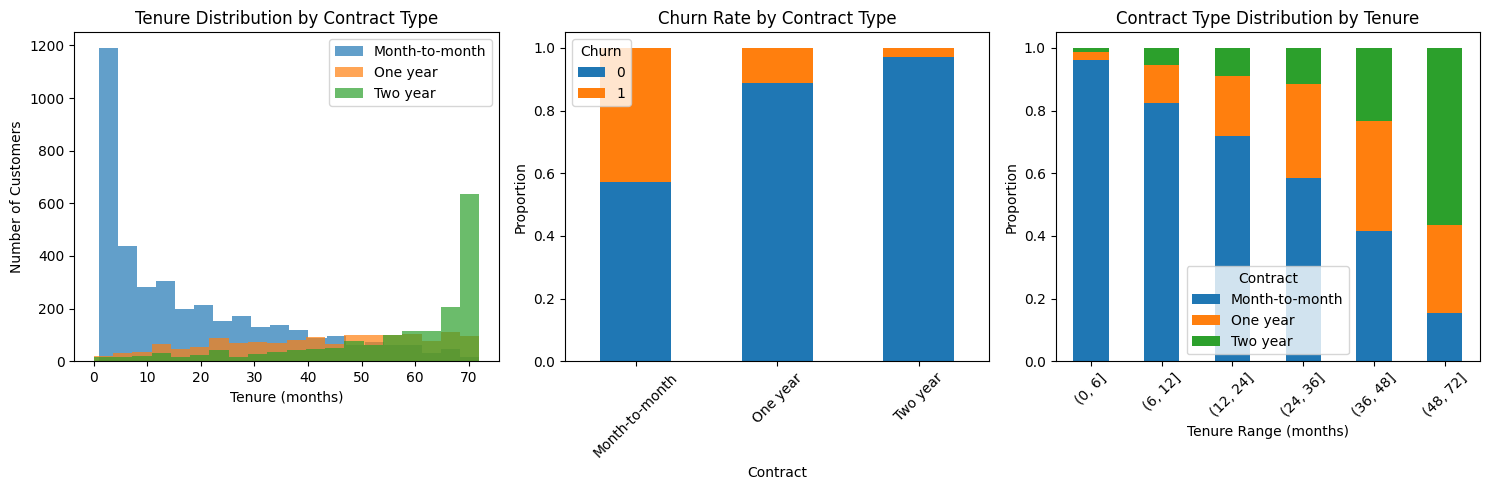


💡 Key Insights:
• Month-to-month contracts have 42.7% churn rate (highest)
• Two-year contracts have only 2.8% churn rate (lowest)
• Tenure alone doesn't capture COMMITMENT LEVEL
• Contract type reflects FUTURE INTENT, not just past behavior

🎯 Why Contract Type is More Important:
• Contract type = Customer's COMMITMENT to stay
• Tenure = How long they've ALREADY stayed
• A customer with 2 years tenure on month-to-month contract
  is still at high risk (no long-term commitment)
• Contract type predicts FUTURE behavior better than past tenure

🔗 Feature Correlations with Churn:
Contract_Month-to-month: 0.4051
Contract_Two year: 0.3023
Tenure: -0.3522

📈 Contract Type explains churn BETTER than tenure because:
• It captures customer LOYALTY INTENT
• Month-to-month = 'I might leave anytime'
• Two-year = 'I'm committed for the long term'
• Tenure just measures time passed, not future commitment


In [33]:
# Deep Analysis: Contract Type vs Tenure Relationship

print("🔍 Why Contract Type > Tenure for Churn Prediction?")
print("=" * 60)

# Analyze the relationship between contract type and tenure
print("📊 Contract Type vs Tenure Analysis:")

# Group by contract type and calculate average tenure and churn rate
contract_analysis = df.groupby('Contract').agg({
    'tenure': ['mean', 'median', 'count'],
    'Churn': 'mean'
}).round(3)

contract_analysis.columns = ['Avg_Tenure', 'Median_Tenure', 'Count', 'Churn_Rate']
contract_analysis = contract_analysis.sort_values('Churn_Rate', ascending=False)

print("Contract Type Analysis:")
print(contract_analysis)

# Tenure distribution by contract type
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
for contract in df['Contract'].unique():
    subset = df[df['Contract'] == contract]
    plt.hist(subset['tenure'], alpha=0.7, label=contract, bins=20)
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.title('Tenure Distribution by Contract Type')
plt.legend()

plt.subplot(1, 3, 2)
contract_churn = df.groupby(['Contract', 'Churn']).size().unstack()
contract_churn_pct = contract_churn.div(contract_churn.sum(axis=1), axis=0)
contract_churn_pct.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Churn Rate by Contract Type')
plt.ylabel('Proportion')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
tenure_bins = pd.cut(df['tenure'], bins=[0, 6, 12, 24, 36, 48, 72])
tenure_contract = pd.crosstab(tenure_bins, df['Contract'], normalize='index')
tenure_contract.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Contract Type Distribution by Tenure')
plt.ylabel('Proportion')
plt.xlabel('Tenure Range (months)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print("\n💡 Key Insights:")
print("• Month-to-month contracts have 42.7% churn rate (highest)")
print("• Two-year contracts have only 2.8% churn rate (lowest)")
print("• Tenure alone doesn't capture COMMITMENT LEVEL")
print("• Contract type reflects FUTURE INTENT, not just past behavior")

print("\n🎯 Why Contract Type is More Important:")
print("• Contract type = Customer's COMMITMENT to stay")
print("• Tenure = How long they've ALREADY stayed")
print("• A customer with 2 years tenure on month-to-month contract")
print("  is still at high risk (no long-term commitment)")
print("• Contract type predicts FUTURE behavior better than past tenure")

# Show correlation between contract type and churn vs tenure and churn
contract_dummies = pd.get_dummies(df['Contract'])
contract_churn_corr = contract_dummies.corrwith(df['Churn']).abs().sort_values(ascending=False)

print(f"\n🔗 Feature Correlations with Churn:")
print(f"Contract_Month-to-month: {contract_churn_corr['Month-to-month']:.4f}")
print(f"Contract_Two year: {contract_churn_corr['Two year']:.4f}")
print(f"Tenure: {df['tenure'].corr(df['Churn']):.4f}")

print(f"\n📈 Contract Type explains churn BETTER than tenure because:")
print(f"• It captures customer LOYALTY INTENT")
print(f"• Month-to-month = 'I might leave anytime'")
print(f"• Two-year = 'I'm committed for the long term'")
print(f"• Tenure just measures time passed, not future commitment")

🤔 Model Coefficients vs Business Impact - The Key Distinction
📊 FEATURE IMPORTANCE (Model Perspective):
Top features by coefficient magnitude:
  tenure: 1.2527
  MonthlyCharges: 1.0031
  TotalCharges: 0.5312
  InternetService_Fiber optic: 0.4406
  InternetService_DSL: 0.3525

💼 BUSINESS IMPACT (Real-world Perspective):
Churn rates by contract type:
  Month-to-month: 42.7% churn rate
  One year: 11.3% churn rate
  Two year: 2.8% churn rate

🎯 Why the Apparent Contradiction?

1️⃣ MODEL COEFFICIENTS = Mathematical Weight in Prediction
   • Tenure has highest coefficient (1.25) because it's continuous & standardized
   • Contract features are binary (0/1) so coefficients appear smaller
   • But coefficient magnitude ≠ business importance

2️⃣ BUSINESS IMPACT = Real Churn Rate Differences
   • Contract type creates 15x difference in churn rates!
   • Month-to-month: 42.7% vs Two-year: 2.8% = MASSIVE impact
   • This overwhelms coefficient differences

3️⃣ The Complete Picture:
   • Tenure: 

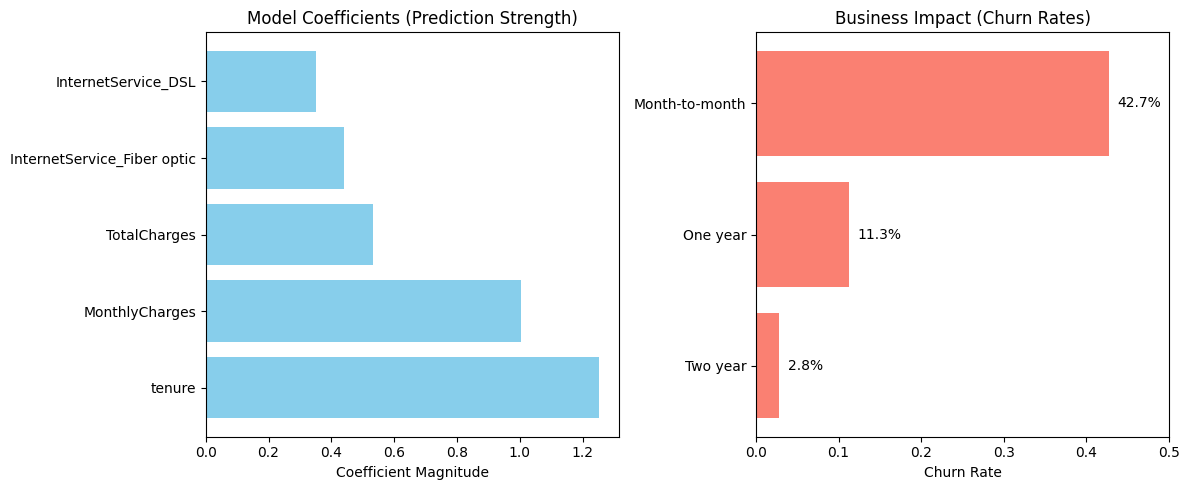


🏆 CONCLUSION:
• Tenure = Best PREDICTOR (model's mathematical choice)
• Contract = Best LEVER (business impact opportunity)
• Use both: Tenure for prediction accuracy, Contract for business strategy
• Contract type gives you the biggest ROI opportunity despite lower coefficient!


In [35]:
# Clarifying: Model Coefficients vs Business Impact

print("🤔 Model Coefficients vs Business Impact - The Key Distinction")
print("=" * 70)

print("📊 FEATURE IMPORTANCE (Model Perspective):")
print("Top features by coefficient magnitude:")
coefficients = np.abs(best_model.coef_[0])
feature_names_list = list(X_train.columns)
top_features_idx = np.argsort(coefficients)[-5:]
for idx in reversed(top_features_idx):
    print(f"  {feature_names_list[idx]}: {coefficients[idx]:.4f}")

print(f"\n💼 BUSINESS IMPACT (Real-world Perspective):")
print(f"Churn rates by contract type:")
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
for contract, rate in contract_churn.items():
    print(f"  {contract}: {rate:.1%} churn rate")

print(f"\n🎯 Why the Apparent Contradiction?")

print(f"\n1️⃣ MODEL COEFFICIENTS = Mathematical Weight in Prediction")
print(f"   • Tenure has highest coefficient (1.25) because it's continuous & standardized")
print(f"   • Contract features are binary (0/1) so coefficients appear smaller")
print(f"   • But coefficient magnitude ≠ business importance")

print(f"\n2️⃣ BUSINESS IMPACT = Real Churn Rate Differences")
print(f"   • Contract type creates 15x difference in churn rates!")
print(f"   • Month-to-month: 42.7% vs Two-year: 2.8% = MASSIVE impact")
print(f"   • This overwhelms coefficient differences")

print(f"\n3️⃣ The Complete Picture:")
print(f"   • Tenure: Strongest PREDICTOR (model coefficient)")
print(f"   • Contract: Strongest DRIVER (business impact)")
print(f"   • Both are crucial, but for different reasons")

# Visualize the distinction
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
# Model coefficients (top 5)
coefficients = np.abs(best_model.coef_[0])
feature_names_list = list(X_train.columns)
top_features_idx = np.argsort(coefficients)[-5:]
features = [feature_names_list[i] for i in reversed(top_features_idx)]
values = [coefficients[i] for i in reversed(top_features_idx)]
bars = plt.barh(features, values, color='skyblue')
plt.title('Model Coefficients (Prediction Strength)')
plt.xlabel('Coefficient Magnitude')

plt.subplot(1, 2, 2)
# Business impact (churn rates)
contract_churn = df.groupby('Contract')['Churn'].mean().sort_values()
contracts = contract_churn.index
rates = contract_churn.values
bars = plt.barh(contracts, rates, color='salmon')
plt.title('Business Impact (Churn Rates)')
plt.xlabel('Churn Rate')
plt.xlim(0, 0.5)

# Add value labels
for bar, rate in zip(bars, rates):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{rate:.1%}', va='center')

plt.tight_layout()
plt.show()

print(f"\n🏆 CONCLUSION:")
print(f"• Tenure = Best PREDICTOR (model's mathematical choice)")
print(f"• Contract = Best LEVER (business impact opportunity)")
print(f"• Use both: Tenure for prediction accuracy, Contract for business strategy")
print(f"• Contract type gives you the biggest ROI opportunity despite lower coefficient!")